# Изучение основ линейной регрессии

Регрессия - метод исследования взаимосвязи между переменными, который позволяет построить математическую модель для предсказания значения одной переменной (зависимой) на основе одной или нескольких других переменных (независимых). Линейная регрессия - наиболее распространённый метод, предполагающий линейную зависимость между переменными. Цель - найти такую прямую линию, которая наилучшим образом описывает данные.

## Цель и задачи работы

Цель: построение простейших моделей регрессии, проведение обучения моделей на реальных данных и оценка их качества.

Задачи:
1. Загрузить датасет из репозитория (например, kaggle.com или аналогичных платформ).
2. Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной. 
3. Провести предобработку данных: удалить пропущенные значения, закодировать категориальные переменные (опционально), нормализовать признаки.
4. Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности (расчет VIF-коэффициента).
5. Построить регрессионные модели (линейная и гребневая). Если целевая переменная - категориальная, то исследовать логистическую регрессию. Разделить на тренировочную и тестовую выборки (80/20 или 70/30). Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: RMSE (Root Mean Square Error), R² (коэффициент детерминации) и MAPE (Mean Absolute Percentage Error).
6. Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA).
7. Повторить шаг 5 (линейная и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.

## Описание данных
Для выполнения работы был выбран датасет [Цены на жилье в Калифорнии (California Housing Prices)](https://www.kaggle.com/datasets/camnugent/california-housing-prices) с платформы Kaggle. Данные хранятся в файле `housing.csv`.

Целевая переменная - средняя стоимость дома в пределах квартала (median_house_value).

Признаки:
1. `longitude` - мера того, насколько далеко к западу находится дом (чем больше, тем дальше на запад);
2. `latitude` - мера того, насколько далеко на севере находится дом (чем больше, тем дальше на север);
3. `housing_median_age` - средний возраст дома в квартале;
4. `total_rooms` - общее количество комнат;
5. `population` - общее количество людей, проживающих в пределах квартала;
6. `households` - общее количество домохозяйств;
7. `median_income` - средний доход домохозяйств в пределах жилого квартала.

---
## 1 Загрузка данных
Загрузим все необходимые для работы библиотеки.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

Загрузим сами данные, отобрав лишь важные для работы переменные, остальные переменные избыточны для данной работы.

In [2]:
df = pd.read_csv("housing.csv")
df_selected = df[["longitude","latitude","housing_median_age","total_rooms","population","households","median_income","median_house_value"]]

Изучим данные.

In [3]:
df_selected.head()

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,565.0,259.0,3.8462,342200.0


---
## 2 Предобработка данных

Проверим наличие пропущенных значений в данных.

In [4]:
print('Количество пропущенных значений:\n',df_selected.isnull().sum())

Количество пропущенных значений:
 longitude             0
latitude              0
housing_median_age    0
total_rooms           0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


Пропущенные значения в данных отсутствуют.

Проверим наличие взаимосвязей между переменными, которые могут исказить результат применения модели.

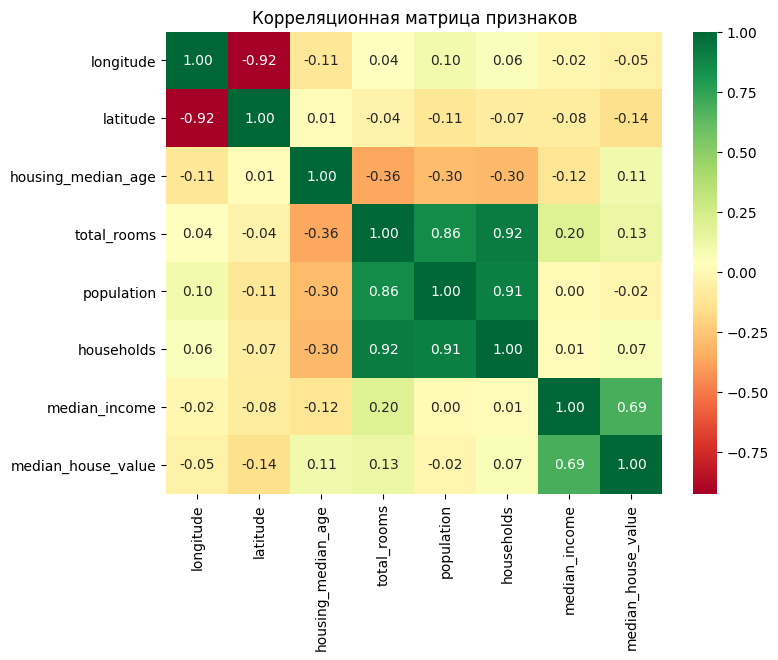

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_selected.corr(), annot=True, cmap="RdYlGn", fmt=".2f")
plt.title("Корреляционная матрица признаков")
plt.show()

Выводы по наличию корреляций:
- `longitude` и `latitude` сильно коррелированы (-0.92), т.к. это признаки географического положения, которые "дублируют" информацию.
- `total_rooms`, `population`, `households` образуют «кластер» с очень высокой корреляцией (0.86–0.92), т.к. где больше населения, там больше домохозяйств и комнат.
- `housing_median_age` и `median_income` почти не коррелируют с другими признаками.

Наличие сильных парных корреляций свидетельствует о потенциальной мультиколлинеарности, что может привести к нестабильности коэффициентов линейной регрессии. Данный аспект нужно проверять после возможного логарифмирования и стандартизации данных.

Поэтому посмотрим на распределения переменных.

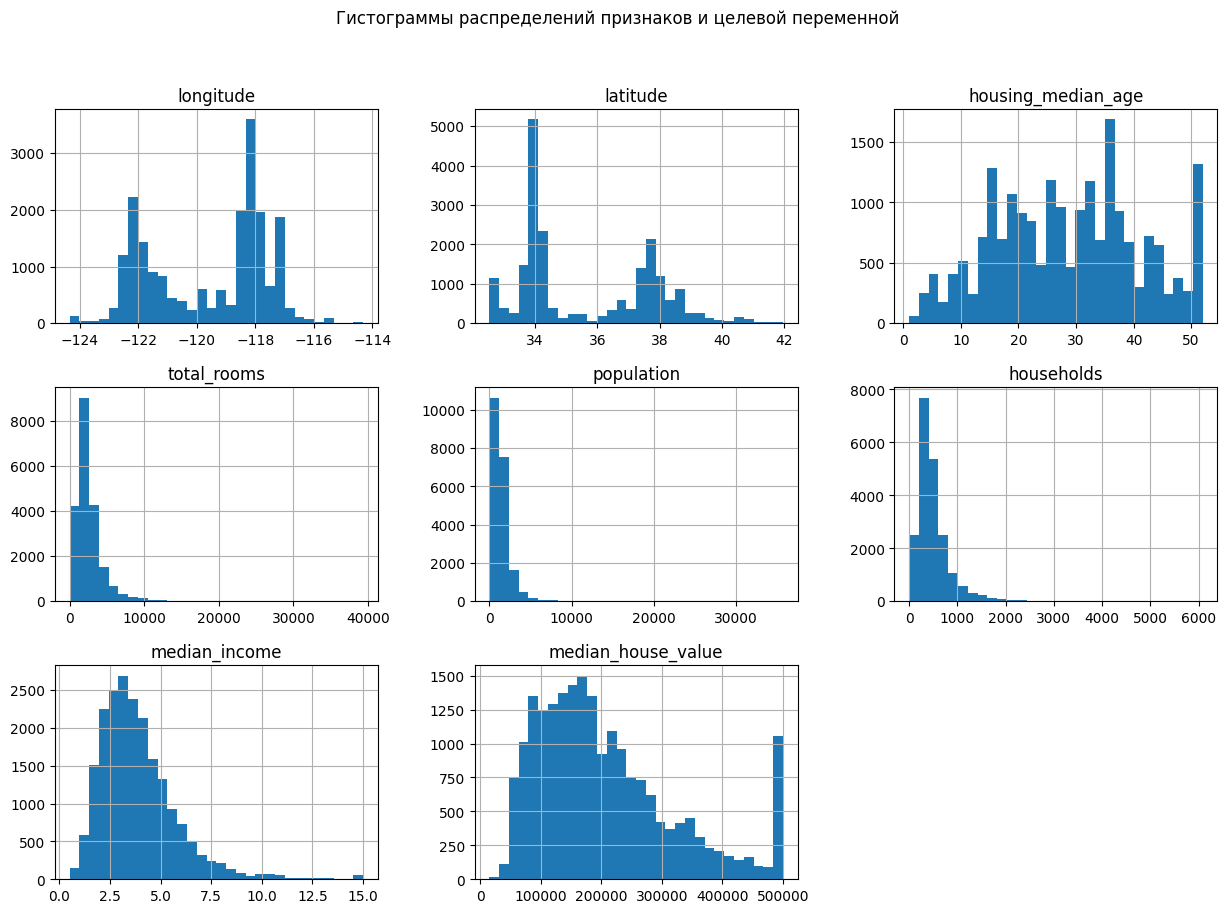

In [6]:
df_selected.hist(bins=30, figsize=(15, 10))
plt.suptitle("Гистограммы распределений признаков и целевой переменной")
plt.show()

Признаки `longitude` и `latitude` демонстрируют бимодальное распределение, что свидетельствует о наличии двух географических кластеров (вероятно, прибрежные и внутренние районы). Линейная регрессия не способна адекватно моделировать бимодальные зависимости без дополнительных преобразований. Однако, мы оставим их как есть.

А вот признаки `total_rooms`, `population`, `households`, `median_income` и целевую перемнную `median_house_value` со скошенными нормальными распределениями мы можем исправить логарифмированием, чтобы улучшить качество модели.

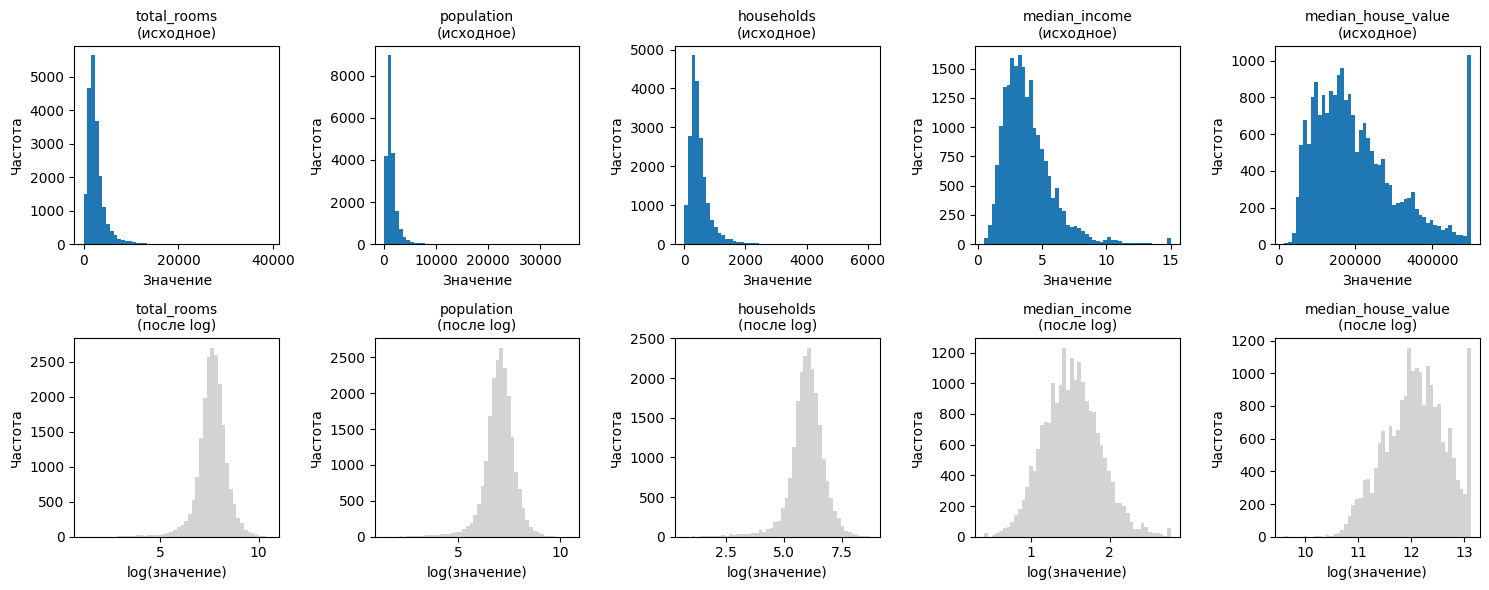

In [7]:
# Список признаков для логарифмирования
features_to_log = ["total_rooms", "population", "households", "median_income", "median_house_value"]

# Создаем копию (чтобы не испортить исходные данные)
df_log = df_selected.copy()

# Логарифмируем все признаки из списка
for feature in features_to_log:
    df_log[feature] = np.log1p(df_log[feature])
    
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, feature in enumerate(features_to_log):
    # Исходное распределение
    axes[0, i].hist(df_selected[feature], bins=50)
    axes[0, i].set_title(f'{feature}\n(исходное)', fontsize=10)
    axes[0, i].set_xlabel('Значение')
    axes[0, i].set_ylabel('Частота')
    
    # Распределение после логарифмирования
    axes[1, i].hist(df_log[feature], bins=50, color='lightgray')
    axes[1, i].set_title(f'{feature}\n(после log)', fontsize=10)
    axes[1, i].set_xlabel('log(значение)')
    axes[1, i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

Логарифмирование прошло успешно.

Выведем описательные статистики.

In [8]:
print("Первичный анализ:")

summary = pd.DataFrame({
    "Среднее": df_selected.mean(numeric_only=True),
    "Медиана": df_selected.median(numeric_only=True),
    "Мода": df_selected.mode().iloc[0],
    "Ст. отклонение": df_selected.std(numeric_only=True)
})

print(summary)

Первичный анализ:
                          Среднее      Медиана        Мода  Ст. отклонение
longitude             -119.569704    -118.4900    -118.310        2.003532
latitude                35.631861      34.2600      34.060        2.135952
housing_median_age      28.639486      29.0000      52.000       12.585558
total_rooms           2635.763081    2127.0000    1527.000     2181.615252
population            1425.476744    1166.0000     891.000     1132.462122
households             499.539680     409.0000     306.000      382.329753
median_income            3.870671       3.5348       3.125        1.899822
median_house_value  206855.816909  179700.0000  500001.000   115395.615874


Как можно заметить, переменные имеют разные масштабы и единицы измерения. В такой ситуации признаки с большими значениями будут иметь больший вес в модели, что исказит результат ее работы. Поэтому после логарифмирования необходимо провести стандартизацию данных.

In [9]:
# Разделяем признаки и целевую переменную
features = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "population",
    "households",
    "median_income"
]

target = "median_house_value"

X = df_log[features]
y = df_log[target]

# Разделение на тренировочную и тестовую выборки (20% данных в тестовую, 80% для обучения)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Класс для нормализации данных
scaler = StandardScaler()

# fit - вычисляет среднее и стандартное отклонение каждого признака, transform - применяет формулу стандартизации
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

df_scaled = pd.DataFrame(
    X_train_scaled,
    columns=features
)

print("Данные после нормализации:\n")
print(df_scaled.head())

Данные после нормализации:

   longitude  latitude  housing_median_age  total_rooms  population  \
0   1.272587 -1.372811            0.348490     0.554436    0.972109   
1   0.709162 -0.876696            1.618118     0.659519    0.210623   
2  -0.447603 -0.460146           -1.952710    -0.112310   -0.281480   
3   1.232698 -1.382172            0.586545    -0.497898    0.314216   
4  -0.108551  0.532084            1.142008     0.191580   -0.343803   

   households  median_income  
0    0.619746      -0.193855  
1    0.885964       0.145668  
2   -0.229101       0.337635  
3   -0.153529      -1.222969  
4   -0.060017      -0.007808  


Рассчитаем также коэффициенты VIF для проверки на мультиколлинеарность.

In [10]:
vif_data = pd.DataFrame()
vif_data["Признак"] = df_scaled.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train_scaled, i)
    for i in range(X_train_scaled.shape[1])
]

print("\nКоэффициенты VIF:\n")
print(vif_data)


Коэффициенты VIF:

              Признак        VIF
0           longitude   9.527380
1            latitude   9.990895
2  housing_median_age   1.225546
3         total_rooms  14.470533
4          population   7.709816
5          households  20.150009
6       median_income   1.946516


`housing_median_age` и `median_income` независимы, т.к. VIF для них меньше 5. Остальные мультиколлинеарны.

Корреляционный анализ выявил сильные парные связи, а VIF подтвердил наличие мультиколлинеарности. Это означает, что в данных присутствуют переменные, выражающие одну и ту же информацию. При построении линейной регрессии без регуляризации коэффициенты могут быть нестабильными и трудно интерпретируемыми.

Проверим это на практике.

---
## 3 Создание и запуск моделей
Создадим две модели и выведем метрики для оценки их качества.

In [11]:
# Расчет метрик - RMSE, R2, MAPE
def evaluate_model(model, X_train, X_test, y_train, y_test):
        # Обучение модели
    model.fit(X_train, y_train)

    # Предсказания в log-пространстве
    y_pred_log = model.predict(X_test)

    # Обратное преобразование
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)

    # Метрики
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    ) * 100

    return {
        "RMSE": rmse,
        "R2": r2,
        "MAPE (%)": mape
    }
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    return {"RMSE": rmse, "R2": r2, "MAPE (%)": mape}

def run_models(X_train, X_test, y_train, y_test, dataset_name):

    models = {
        "Линейная регрессия": LinearRegression(),
        "Гребневая регрессия": Ridge(alpha=1)
    }

    results = []

    for name, model in models.items():
        metrics = evaluate_model(model, X_train, X_test, y_train, y_test)
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
        metrics["R2_CV_mean"] = cv_scores.mean()
        metrics["R2_CV"] = np.round(cv_scores, 6)
        results.append({
            "Модель": name,
            "Набор данных": dataset_name,
            **metrics
        })

    return pd.DataFrame(results)

results_scaled = run_models(X_train_scaled, X_test_scaled, y_train, y_test, "До PCA")

print("\nРезультаты до PCA:\n")
print(results_scaled)


Результаты до PCA:

                Модель Набор данных          RMSE        R2   MAPE (%)  \
0   Линейная регрессия       До PCA  67446.618792  0.652853  25.813558   
1  Гребневая регрессия       До PCA  67451.841808  0.652799  25.814797   

   R2_CV_mean                                              R2_CV  
0    0.673406  [0.682968, 0.66933, 0.671801, 0.678976, 0.663957]  
1    0.673407  [0.68295, 0.669339, 0.671781, 0.678994, 0.663971]  


Как мы видим, регуляризация, к сожалению, не улучшила модель на исходных данных. Более того, метрики практически идентичны с точностью до плавающей точки. Вероятно, это произошло потому, что мультиколлинеарность не приводит к нестабильности коэффициентов в данном случае - все коррелированные признаки вносят вклад в предсказание цены в одном направлении. Попробуем все же избавиться от мультиколлинеарности и вновь построить обе модели.

Используем метод главных компонент (PCA) для создания некоррелированных признаков и сокращения размерности, что теоретически должно улучшить стабильность и интерпретируемость коэффициентов регрессии.


Данные до PCA: (16512, 7)
Данные после PCA: (16512, 4)

Доля объяснённой дисперсии:
[0.42613365 0.27144658 0.15272652 0.12051715]

Суммарно объясняется:
0.9708238999124343


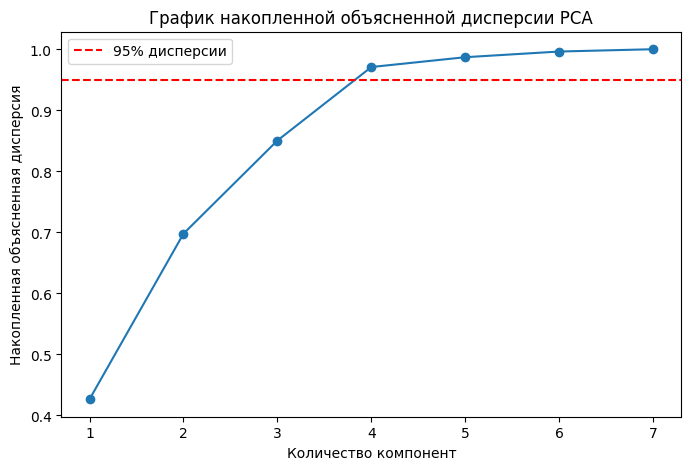

In [12]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print("\nДанные до PCA:", X_train_scaled.shape)
print("Данные после PCA:", X_train_pca.shape)

explained_var = pca.explained_variance_ratio_
print("\nДоля объяснённой дисперсии:")
print(explained_var)

print("\nСуммарно объясняется:")
print(explained_var.sum())

# PCA на всех компонентах
pca_full = PCA().fit(X_train_scaled)
# Накопленная дисперсия
cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)
# Линия уровня 95%
plt.axhline(
    y=0.95,
    color="red",
    linestyle="--",
    label="95% дисперсии"
)
plt.xlabel("Количество компонент")
plt.ylabel("Накопленная объясненная дисперсия")
plt.title("График накопленной объясненной дисперсии PCA")
plt.legend()
plt.show()

Как видно из графика, после 4-й компоненты рост накопленной объяснённой дисперсии существенно замедляется. Это означает, что последующие компоненты вносят значительно меньший вклад в объяснение вариативности данных и содержат меньше полезной информации. Таким образом, использование первых 4 компонент позволяет сохранить основную часть информации исходных данных при снижении размерности пространства признаков.

Попробуем запустить модели на преобразованных с помощью PCA данных.

In [13]:
results_pca = run_models(X_train_pca, X_test_pca, y_train, y_test, "После PCA")
comparison_df = pd.concat([results_scaled, results_pca], ignore_index=True)
print("Сравнение моделей до и после PCA:")
print(comparison_df)

Сравнение моделей до и после PCA:
                Модель Набор данных          RMSE        R2   MAPE (%)  \
0   Линейная регрессия       До PCA  67446.618792  0.652853  25.813558   
1  Гребневая регрессия       До PCA  67451.841808  0.652799  25.814797   
2   Линейная регрессия    После PCA  81744.096206  0.490075  32.230662   
3  Гребневая регрессия    После PCA  81743.618381  0.490081  32.230890   

   R2_CV_mean                                              R2_CV  
0    0.673406  [0.682968, 0.66933, 0.671801, 0.678976, 0.663957]  
1    0.673407  [0.68295, 0.669339, 0.671781, 0.678994, 0.663971]  
2    0.518224   [0.527231, 0.51739, 0.501265, 0.52529, 0.519942]  
3    0.518224  [0.527229, 0.517391, 0.501267, 0.525289, 0.519...  


---
## 4 Выводы
### 4.1 Сравнение линейной и гребневой регрессии
Линейная и гребневая регрессии показали практически одинаковые результаты, значит, мультиколлинеарность в данных либо слабо выражена, либо регуляризация с альфа=1 была недостаточной для улучшения качества.

### 4.2 Влияние PCA на качество моделей
Применение PCA ухудшило качество моделей как линейной, так и гребневой регрессии по всем трем метрикам:
- значение RMSE увеличилось с 67 до 81 тыс,
- значение R^2 снизилось с 65 до 49%,
- ошибка MAPE выросла с 25 до 32%.

Таким образом, применение PCA привело к существенному ухудшению прогностической способности моделей.

### 4.3 Практическая пригодность моделей
Для многих практических задач в сфере недвижимости целевым уровнем MAPE является 15-20%. Полученные значения 25-32% указывают на то, что модель пригодна для исследования факторов, влияющих на ценообразование, но недостаточно точна для прямой оценки стоимости конкретных объектов недвижимости.